<a href="https://colab.research.google.com/github/OJB-Quantum/Monte-Carlo-Sim/blob/main/CUDA_Accelerated_Proximity_Effect_Correction_(PEC)_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2025)

Open Access (CC-BY-4.0)

In [9]:
!nvidia-smi

Fri Dec 19 16:05:42 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   55C    P0             28W /   72W |     241MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [10]:
import re
import subprocess
import sys


def detect_cuda_major() -> int:
    """Detect CUDA major version from nvidia-smi; default to 12 if unknown."""
    try:
        out = subprocess.check_output(["nvidia-smi"], text=True)
        match = re.search(r"CUDA Version:\s+(\d+)\.", out)
        if match:
            return int(match.group(1))
    except Exception:
        pass
    # Colab has been on CUDA 12.x in recent runtimes; default conservatively.
    return 12


cuda_major = detect_cuda_major()
pkg = "cupy-cuda12x" if cuda_major >= 12 else "cupy-cuda11x"
print(f"Detected CUDA major = {cuda_major}, installing {pkg} ...")

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
print("CuPy install complete.")


Detected CUDA major = 12, installing cupy-cuda12x ...
CuPy install complete.


In [11]:
import math
from dataclasses import dataclass
from typing import Tuple

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

import cupy as cp

# Required by your request: set DPI to 200 via rcParams.
mpl.rcParams.update({
    "figure.dpi": 200,
    "savefig.dpi": 200,
})

# Optional: make binary images look like masks by default.
mpl.rcParams.update({
    "image.cmap": "gray",
})

print("NumPy:", np.__version__)
print("CuPy:", cp.__version__)

dev = cp.cuda.Device()
props = cp.cuda.runtime.getDeviceProperties(dev.id)
gpu_name = props["name"].decode("utf-8") if isinstance(props["name"], (bytes, bytearray)) else str(props["name"])
print("Active GPU:", gpu_name)


NumPy: 2.0.2
CuPy: 13.6.0
Active GPU: NVIDIA L4


In [12]:
@dataclass(frozen=True)
class SimConfig:
    grid_n: int = 512
    pixel_nm: float = 10.0

    # Optical model
    opt_sigma_nm: float = 35.0
    opt_threshold: float = 0.50
    opt_sigmoid_slope: float = 0.08
    opt_photons_per_pixel: float = 800.0
    opt_opc_iters: int = 60
    opt_opc_step: float = 0.50

    # E-beam model
    eb_sigma_f_nm: float = 12.0
    eb_sigma_b_nm: float = 140.0
    eb_eta: float = 0.20
    eb_threshold: float = 0.50
    eb_reg_lambda: float = 3.0e-3
    eb_dose_clip: float = 3.0

    # Monte Carlo
    mc_electrons_total: int = 2_000_000
    mc_chunk_size: int = 400_000

    # Reproducibility
    seed: int = 7


CFG = SimConfig()


def to_cpu(x):
    """Convert CuPy array -> NumPy array for plotting."""
    return cp.asnumpy(x) if isinstance(x, cp.ndarray) else x


def nm_to_px(length_nm: float, pixel_nm: float) -> float:
    """Convert physical length (nm) to pixels."""
    return float(length_nm) / float(pixel_nm)


In [13]:
def draw_rect(img: cp.ndarray, x0: int, x1: int, y0: int, y1: int, value: float = 1.0) -> None:
    """Draw an axis-aligned filled rectangle into img."""
    img[y0:y1, x0:x1] = value


def make_h_plus_pattern(
    shape: Tuple[int, int],
    thickness_px: int,
    h_height_px: int,
    h_width_px: int,
    plus_size_px: int,
    gap_px: int,
) -> cp.ndarray:
    """
    Create a binary target with an 'H' and a '+' separated by a small gap,
    intentionally close enough to show proximity interactions.
    """
    ny, nx = shape
    pat = cp.zeros((ny, nx), dtype=cp.float32)

    cy, cx = ny // 2, nx // 2

    # Place H slightly left of center
    h_cx = cx - (h_width_px // 2 + gap_px // 2)
    h_cy = cy
    x_left = h_cx - h_width_px // 2
    x_right = h_cx + h_width_px // 2 - thickness_px
    y0 = h_cy - h_height_px // 2
    y1 = h_cy + h_height_px // 2

    # Two vertical bars
    draw_rect(pat, x_left, x_left + thickness_px, y0, y1, 1.0)
    draw_rect(pat, x_right, x_right + thickness_px, y0, y1, 1.0)

    # Crossbar
    y_cross0 = h_cy - thickness_px // 2
    y_cross1 = y_cross0 + thickness_px
    draw_rect(pat, x_left, x_right + thickness_px, y_cross0, y_cross1, 1.0)

    # Place '+' slightly right of center
    p_cx = cx + (plus_size_px // 2 + gap_px // 2)
    p_cy = cy
    half = plus_size_px // 2

    # Vertical stroke of plus
    draw_rect(
        pat,
        p_cx - thickness_px // 2,
        p_cx - thickness_px // 2 + thickness_px,
        p_cy - half,
        p_cy + half,
        1.0,
    )

    # Horizontal stroke of plus
    draw_rect(
        pat,
        p_cx - half,
        p_cx + half,
        p_cy - thickness_px // 2,
        p_cy - thickness_px // 2 + thickness_px,
        1.0,
    )

    return pat


ny = nx = CFG.grid_n
thickness_px = int(round(nm_to_px(80.0, CFG.pixel_nm)))  # intentionally chunky so it is readable
h_height_px = int(round(nm_to_px(1200.0, CFG.pixel_nm)))
h_width_px = int(round(nm_to_px(700.0, CFG.pixel_nm)))
plus_size_px = int(round(nm_to_px(900.0, CFG.pixel_nm)))
gap_px = int(round(nm_to_px(250.0, CFG.pixel_nm)))

target = make_h_plus_pattern(
    shape=(ny, nx),
    thickness_px=thickness_px,
    h_height_px=h_height_px,
    h_width_px=h_width_px,
    plus_size_px=plus_size_px,
    gap_px=gap_px,
)

print("Target created on GPU:", target.shape, target.dtype)


Target created on GPU: (512, 512) float32


In [14]:
def gaussian_psf(shape: Tuple[int, int], sigma_px: float) -> cp.ndarray:
    """Centered 2D Gaussian PSF normalized to sum=1."""
    ny, nx = shape
    y = cp.arange(ny) - ny // 2
    x = cp.arange(nx) - nx // 2
    yy, xx = cp.meshgrid(y, x, indexing="ij")
    psf = cp.exp(-(xx**2 + yy**2) / (2.0 * float(sigma_px)**2))
    psf = psf / cp.sum(psf)
    return psf.astype(cp.float32)


def double_gaussian_psf(
    shape: Tuple[int, int],
    sigma_f_px: float,
    sigma_b_px: float,
    eta: float,
) -> cp.ndarray:
    """
    Mixture PSF: (1-eta) * G(sigma_f) + eta * G(sigma_b), normalized.
    """
    psf_f = gaussian_psf(shape, sigma_f_px)
    psf_b = gaussian_psf(shape, sigma_b_px)
    psf = (1.0 - float(eta)) * psf_f + float(eta) * psf_b
    psf = psf / cp.sum(psf)
    return psf.astype(cp.float32)


def psf_fft(psf: cp.ndarray) -> cp.ndarray:
    """FFT of a centered PSF, using ifftshift so convolution is correct."""
    return cp.fft.fft2(cp.fft.ifftshift(psf))


def fft_convolve2d(img: cp.ndarray, psf_f: cp.ndarray) -> cp.ndarray:
    """2D convolution using FFT: out = ifft(fft(img)*fft(psf))."""
    out = cp.fft.ifft2(cp.fft.fft2(img) * psf_f)
    return cp.real(out).astype(cp.float32)


# Optical PSF
opt_sigma_px = nm_to_px(CFG.opt_sigma_nm, CFG.pixel_nm)
opt_psf = gaussian_psf((ny, nx), opt_sigma_px)
opt_psf_f = psf_fft(opt_psf)

# E-beam PSF
eb_sigma_f_px = nm_to_px(CFG.eb_sigma_f_nm, CFG.pixel_nm)
eb_sigma_b_px = nm_to_px(CFG.eb_sigma_b_nm, CFG.pixel_nm)
eb_psf = double_gaussian_psf((ny, nx), eb_sigma_f_px, eb_sigma_b_px, CFG.eb_eta)
eb_psf_f = psf_fft(eb_psf)

print("Optical sigma (px):", float(opt_sigma_px))
print("E-beam sigma_f (px), sigma_b (px):", float(eb_sigma_f_px), float(eb_sigma_b_px))


Optical sigma (px): 3.5
E-beam sigma_f (px), sigma_b (px): 1.2 14.0


In [15]:
def sigmoid(x: cp.ndarray) -> cp.ndarray:
    return 1.0 / (1.0 + cp.exp(-x))


def simulate_optical_monte_carlo(
    mask: cp.ndarray,
    psf_f: cp.ndarray,
    photons_per_pixel: float,
    threshold: float,
    seed: int,
) -> Tuple[cp.ndarray, cp.ndarray, cp.ndarray]:
    """
    Optical simulation:
      expected aerial = conv(mask, PSF)
      noisy aerial ~ Poisson(photons_per_pixel * expected) / photons_per_pixel
      printed = noisy >= threshold
    """
    expected = fft_convolve2d(mask, psf_f)
    expected = cp.clip(expected, 0.0, 1.0)

    rng = cp.random.default_rng(seed)
    lam = cp.clip(expected * float(photons_per_pixel), 0.0, None)
    counts = rng.poisson(lam=lam)
    noisy = counts.astype(cp.float32) / float(photons_per_pixel)

    printed = (noisy >= float(threshold)).astype(cp.float32)
    return expected, noisy, printed


def opc_ilt_grayscale(
    target_binary: cp.ndarray,
    psf_f: cp.ndarray,
    threshold: float,
    slope: float,
    iters: int,
    step: float,
    seed: int,
) -> cp.ndarray:
    """
    Simplified inverse-lithography-style OPC:
      - mask is grayscale in [0,1]
      - forward: aerial = conv(mask, PSF)
      - resist: printed_soft = sigmoid((aerial-threshold)/slope)
      - minimize 0.5||target - printed_soft||^2 via gradient descent
    """
    rng = cp.random.default_rng(seed)
    mask = target_binary.astype(cp.float32).copy()

    # Small random dither can help avoid some flat spots in early iterations.
    mask = cp.clip(mask + 0.01 * rng.standard_normal(mask.shape, dtype=cp.float32), 0.0, 1.0)

    thr = float(threshold)
    sl = float(slope)

    for _ in range(int(iters)):
        aerial = fft_convolve2d(mask, psf_f)
        printed_soft = sigmoid((aerial - thr) / sl)

        error = printed_soft - target_binary
        dprinted_daerial = (printed_soft * (1.0 - printed_soft)) / sl

        # dL/daerial = error * dprinted/daerial  (since L=0.5||error||^2)
        grad_aerial = error * dprinted_daerial

        # Approximate adjoint for symmetric PSF is another convolution with PSF
        grad_mask = fft_convolve2d(grad_aerial, psf_f)

        mask = mask - float(step) * grad_mask
        mask = cp.clip(mask, 0.0, 1.0)

    return mask


# Optical: uncorrected (mask == target)
opt_expected_unc, opt_noisy_unc, opt_print_unc = simulate_optical_monte_carlo(
    mask=target,
    psf_f=opt_psf_f,
    photons_per_pixel=CFG.opt_photons_per_pixel,
    threshold=CFG.opt_threshold,
    seed=CFG.seed,
)

# Optical: corrected mask via OPC/ILT-style optimization
opt_mask_corr = opc_ilt_grayscale(
    target_binary=target,
    psf_f=opt_psf_f,
    threshold=CFG.opt_threshold,
    slope=CFG.opt_sigmoid_slope,
    iters=CFG.opt_opc_iters,
    step=CFG.opt_opc_step,
    seed=CFG.seed,
)

opt_expected_cor, opt_noisy_cor, opt_print_cor = simulate_optical_monte_carlo(
    mask=opt_mask_corr,
    psf_f=opt_psf_f,
    photons_per_pixel=CFG.opt_photons_per_pixel,
    threshold=CFG.opt_threshold,
    seed=CFG.seed + 1,
)


In [16]:
import cupy as cp


def tikhonov_deconvolution_dose(
    target_energy: cp.ndarray,
    psf_f: cp.ndarray,
    reg_lambda: float,
    dose_clip: float,
) -> cp.ndarray:
    """
    Regularized inverse filtering in frequency domain:
      dose_hat = target_hat * conj(psf_hat) / (|psf_hat|^2 + lambda)

    Then clip to [0, dose_clip] to avoid unphysical negative doses and spikes.
    """
    target_energy = target_energy.astype(cp.float32, copy=False)

    y_f = cp.fft.fft2(target_energy)
    h_f = psf_f

    denom = (cp.abs(h_f) ** 2) + float(reg_lambda)
    x_f = y_f * cp.conj(h_f) / denom

    dose = cp.real(cp.fft.ifft2(x_f)).astype(cp.float32, copy=False)
    dose = cp.clip(dose, 0.0, float(dose_clip))
    return dose


def _rng_uniform(rng: object, size: int) -> cp.ndarray:
    """Uniform[0,1) samples as float32, with fallback for older CuPy RNG APIs."""
    if hasattr(rng, "random"):
        u = rng.random(size)
    else:
        u = cp.random.random(size)
    return u.astype(cp.float32, copy=False)


def _rng_standard_normal(rng: object, size: int) -> cp.ndarray:
    """Standard normal N(0,1) samples as float32, with fallbacks."""
    if hasattr(rng, "standard_normal"):
        z = rng.standard_normal(size)
    elif hasattr(rng, "normal"):
        # Some RNGs have normal but not standard_normal.
        z = rng.normal(0.0, 1.0, size=size)
    else:
        z = cp.random.standard_normal(size)
    return z.astype(cp.float32, copy=False)


def mc_ebeam_deposited_energy(
    dose: cp.ndarray,
    sigma_f_px: float,
    sigma_b_px: float,
    eta: float,
    n_electrons_total: int,
    chunk_size: int,
    seed: int,
) -> cp.ndarray:
    """
    Monte Carlo electron landing model:
      1) sample a base pixel with probability proportional to dose
      2) sample a scatter displacement from a mixture of Gaussians
      3) land in a new pixel, histogram counts
      4) scale histogram so total deposited energy matches sum(dose)

    This is a proximity-function-based Monte Carlo consistent with PSF thinking.
    """
    ny, nx = dose.shape
    n_pix = int(ny * nx)

    weights = cp.clip(dose.ravel(), 0.0, None).astype(cp.float32, copy=False)
    total_weight = float(cp.sum(weights).get())
    if total_weight <= 0.0:
        raise ValueError("Dose sum is zero; cannot run Monte Carlo sampling.")

    # CDF for inverse transform sampling.
    cdf = cp.cumsum(weights)
    cdf_total = cdf[-1]  # stays on GPU

    rng = cp.random.default_rng(seed)

    counts_total = cp.zeros((n_pix,), dtype=cp.int64)

    eta_f = float(eta)
    sf = float(sigma_f_px)
    sb = float(sigma_b_px)

    n_done = 0
    n_electrons_total = int(n_electrons_total)

    while n_done < n_electrons_total:
        m = int(min(int(chunk_size), n_electrons_total - n_done))

        # Sample base pixel proportional to dose.
        u = _rng_uniform(rng, m) * cdf_total
        base_idx = cp.searchsorted(cdf, u).astype(cp.int32, copy=False)

        y0 = base_idx // nx
        x0 = base_idx - y0 * nx

        # Mixture of forward/backscatter.
        choose_back = (_rng_uniform(rng, m) < eta_f)
        sigma = cp.where(choose_back, sb, sf).astype(cp.float32, copy=False)

        # FIX: Generator may not have rng.normal; use standard_normal * sigma instead.
        dx = _rng_standard_normal(rng, m) * sigma
        dy = _rng_standard_normal(rng, m) * sigma

        x1 = cp.clip(x0 + cp.rint(dx).astype(cp.int32, copy=False), 0, nx - 1)
        y1 = cp.clip(y0 + cp.rint(dy).astype(cp.int32, copy=False), 0, ny - 1)

        landed_idx = (y1 * nx + x1).astype(cp.int32, copy=False)
        counts_chunk = cp.bincount(landed_idx, minlength=n_pix)

        counts_total += counts_chunk
        n_done += m

    # Scale counts so sum(energy_mc) == sum(dose), matching normalized PSF convolution.
    energy_mc = counts_total.astype(cp.float32, copy=False).reshape((ny, nx))
    energy_mc *= (total_weight / float(n_electrons_total))
    return energy_mc


# E-beam: uncorrected dose
eb_dose_unc = target.copy()

# Expected deposited energy (analytic / deterministic)
eb_energy_expected_unc = fft_convolve2d(eb_dose_unc, eb_psf_f)

# Monte Carlo deposited energy
eb_energy_mc_unc = mc_ebeam_deposited_energy(
    dose=eb_dose_unc,
    sigma_f_px=eb_sigma_f_px,
    sigma_b_px=eb_sigma_b_px,
    eta=CFG.eb_eta,
    n_electrons_total=CFG.mc_electrons_total,
    chunk_size=CFG.mc_chunk_size,
    seed=CFG.seed,
)

# E-beam: PEC corrected dose by regularized deconvolution
eb_dose_cor = tikhonov_deconvolution_dose(
    target_energy=target,
    psf_f=eb_psf_f,
    reg_lambda=CFG.eb_reg_lambda,
    dose_clip=CFG.eb_dose_clip,
)

eb_energy_expected_cor = fft_convolve2d(eb_dose_cor, eb_psf_f)
eb_energy_mc_cor = mc_ebeam_deposited_energy(
    dose=eb_dose_cor,
    sigma_f_px=eb_sigma_f_px,
    sigma_b_px=eb_sigma_b_px,
    eta=CFG.eb_eta,
    n_electrons_total=CFG.mc_electrons_total,
    chunk_size=CFG.mc_chunk_size,
    seed=CFG.seed + 1,
)

# Threshold to get "printed" patterns (for quick visual comparison)
eb_print_unc = (eb_energy_mc_unc >= CFG.eb_threshold).astype(cp.float32)
eb_print_cor = (eb_energy_mc_cor >= CFG.eb_threshold).astype(cp.float32)

In [17]:
def iou(a: np.ndarray, b: np.ndarray, thr: float = 0.5) -> float:
    aa = (a >= thr)
    bb = (b >= thr)
    inter = np.logical_and(aa, bb).sum()
    union = np.logical_or(aa, bb).sum()
    return float(inter) / float(union) if union > 0 else 0.0


t_cpu = to_cpu(target)

metrics = []
metrics.append((
    "Optical",
    "Uncorrected",
    iou(t_cpu, to_cpu(opt_print_unc), 0.5),
    float(np.mean(np.abs(t_cpu - to_cpu(opt_print_unc)))),
))
metrics.append((
    "Optical",
    "Corrected",
    iou(t_cpu, to_cpu(opt_print_cor), 0.5),
    float(np.mean(np.abs(t_cpu - to_cpu(opt_print_cor)))),
))
metrics.append((
    "E-beam",
    "Uncorrected",
    iou(t_cpu, to_cpu(eb_print_unc), 0.5),
    float(np.mean(np.abs(t_cpu - to_cpu(eb_print_unc)))),
))
metrics.append((
    "E-beam",
    "Corrected",
    iou(t_cpu, to_cpu(eb_print_cor), 0.5),
    float(np.mean(np.abs(t_cpu - to_cpu(eb_print_cor)))),
))

print("Metrics table")
print("System   Variant       IoU(printed,target)   MeanAbsError(printed,target)")
for sysname, variant, iou_val, mae_val in metrics:
    print(f"{sysname:<8} {variant:<12} {iou_val:<20.8f} {mae_val:<.8f}")


Metrics table
System   Variant       IoU(printed,target)   MeanAbsError(printed,target)
Optical  Uncorrected  0.92614980           0.00107193
Optical  Corrected    0.96939314           0.00044250
E-beam   Uncorrected  0.98473896           0.00021744
E-beam   Corrected    0.79100361           0.00375748


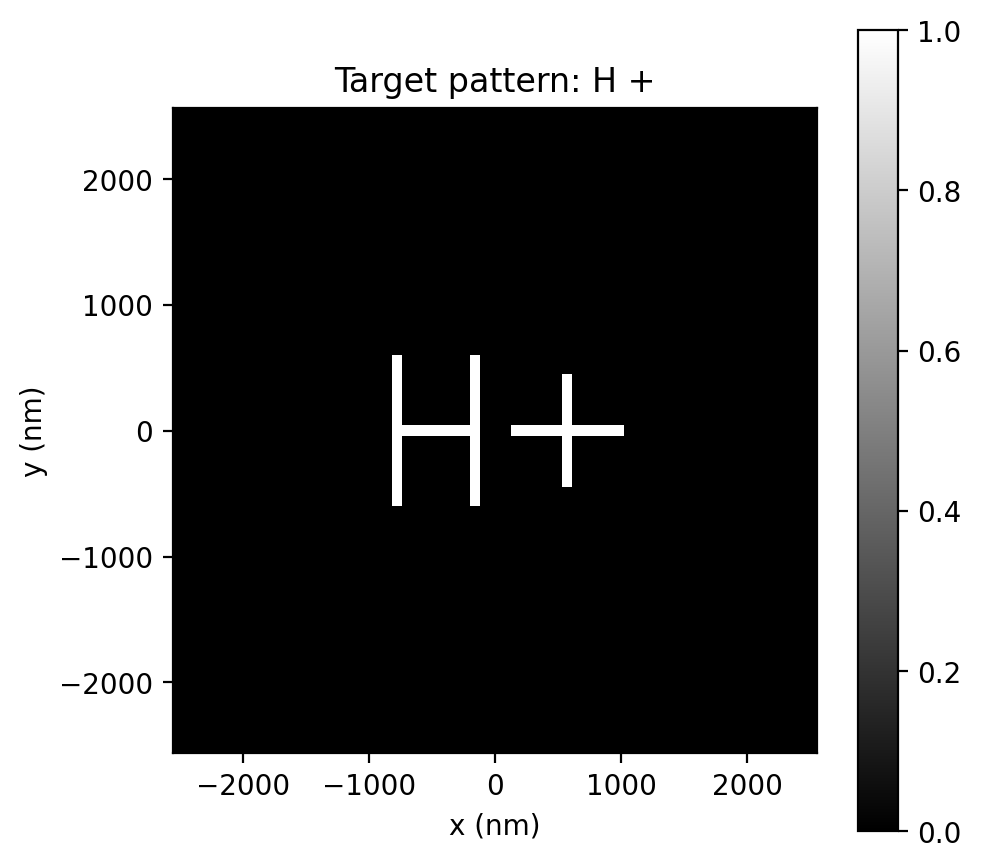

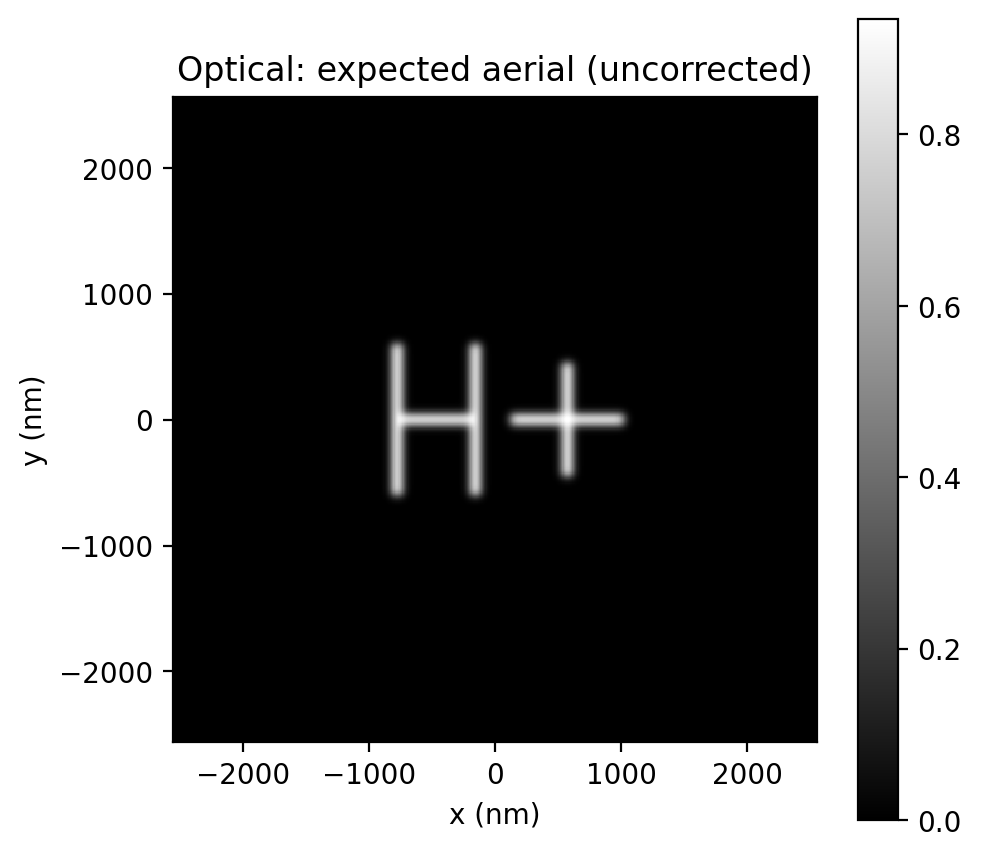

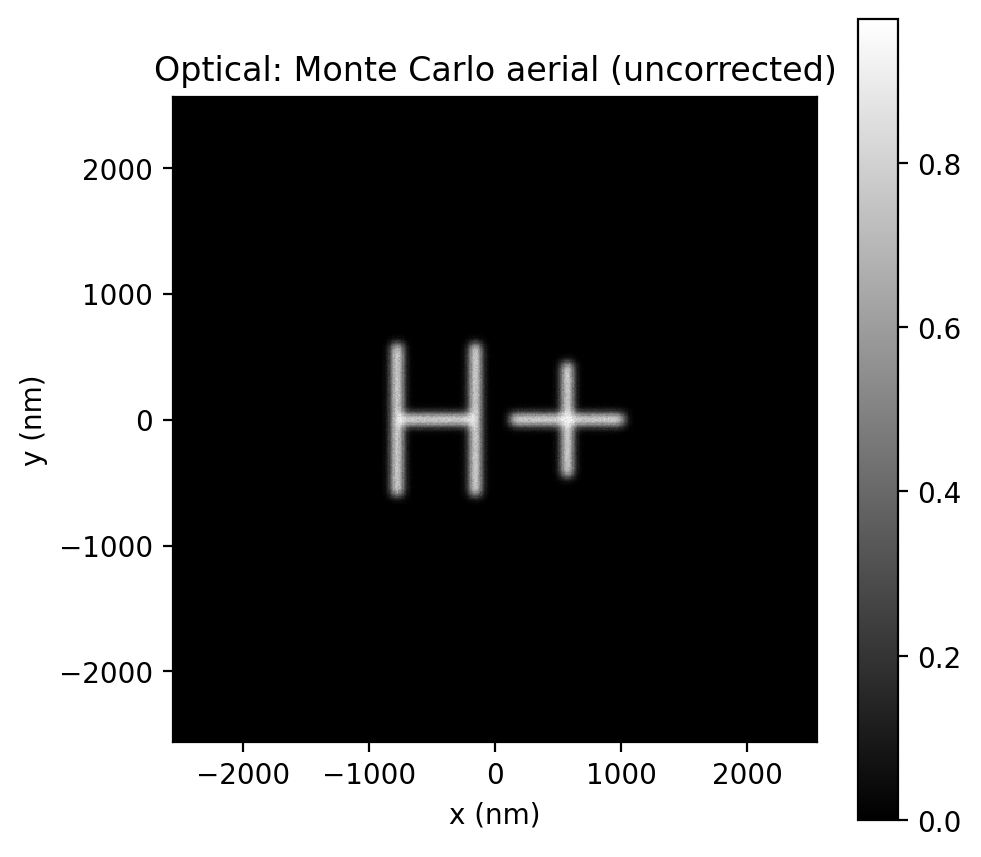

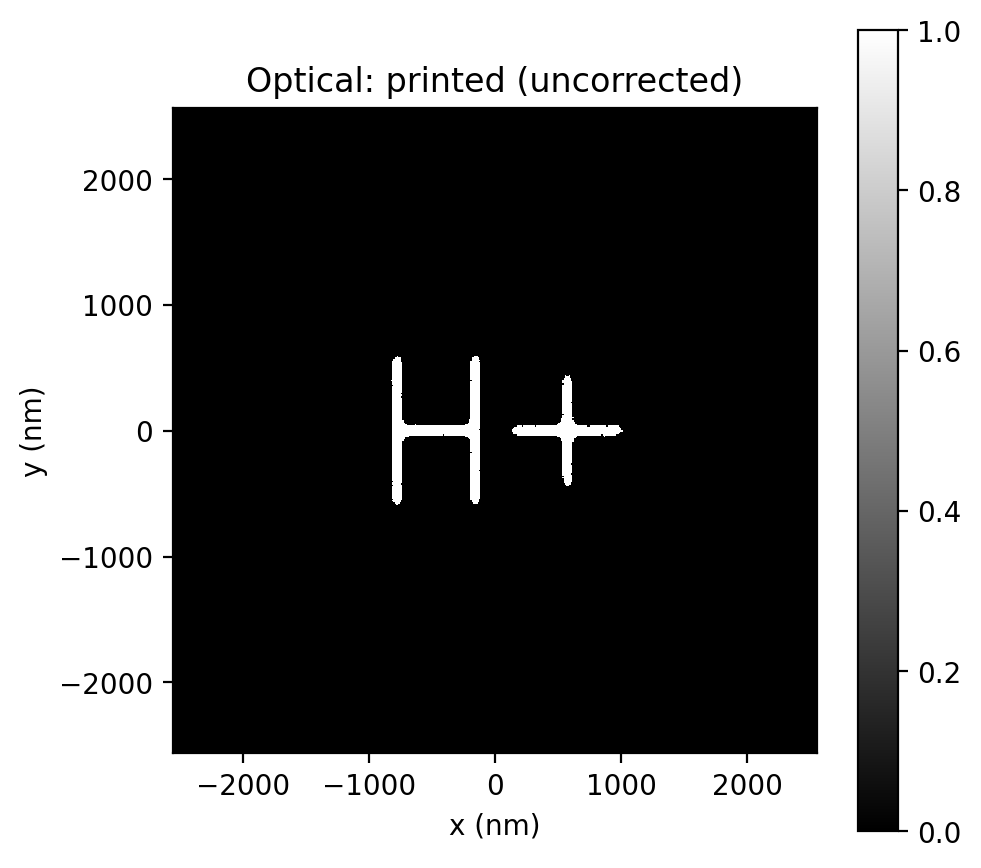

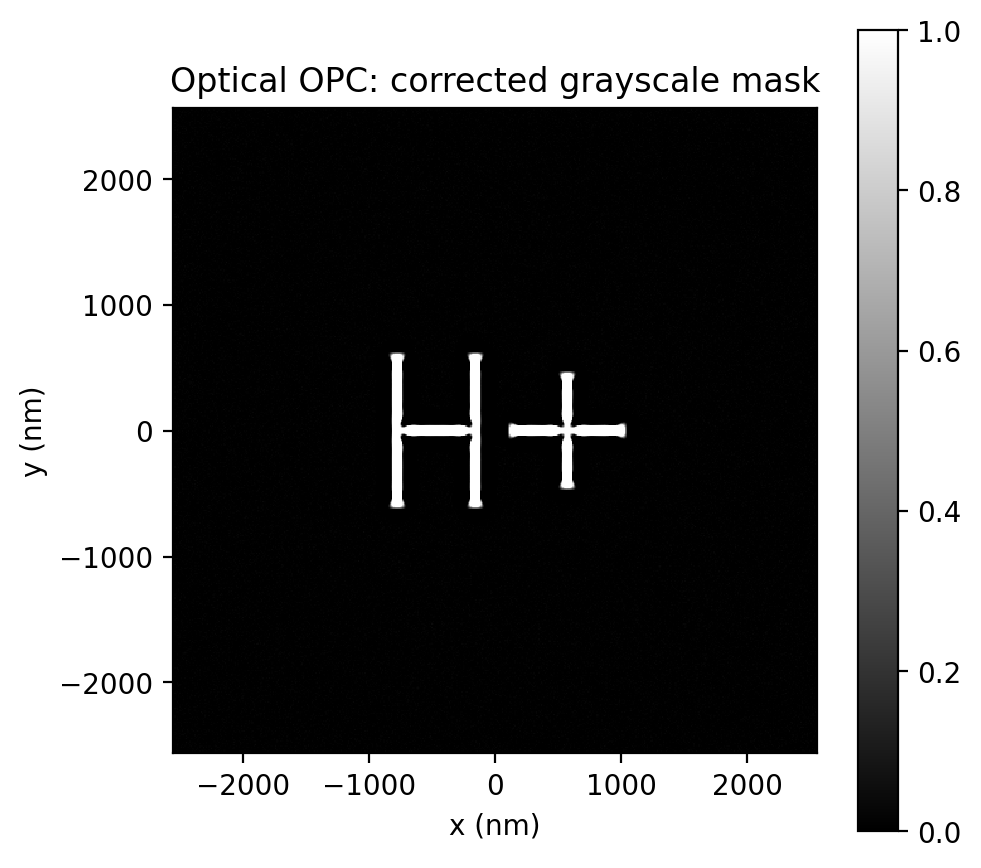

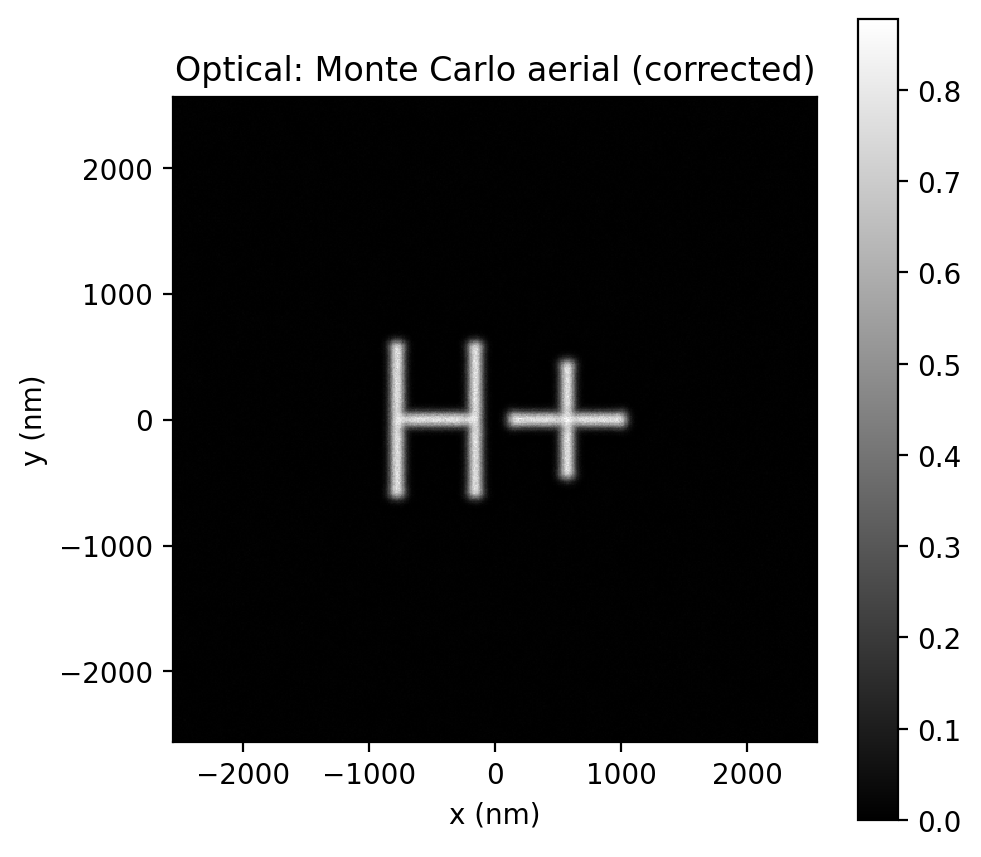

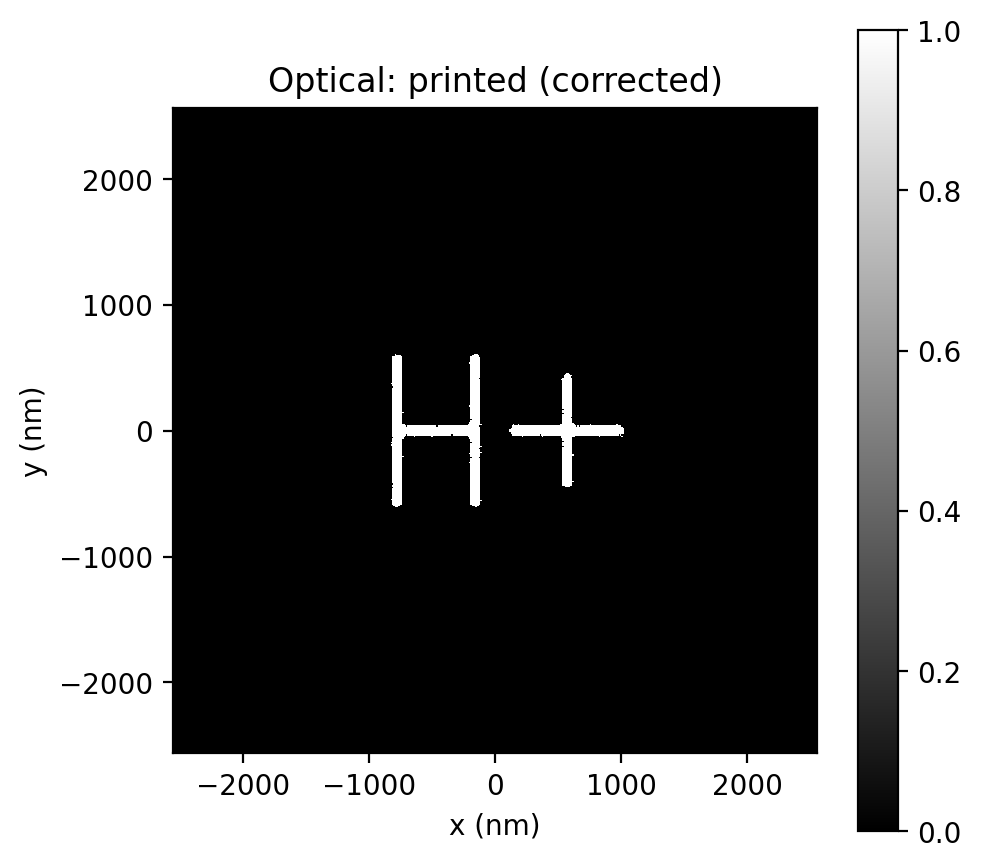

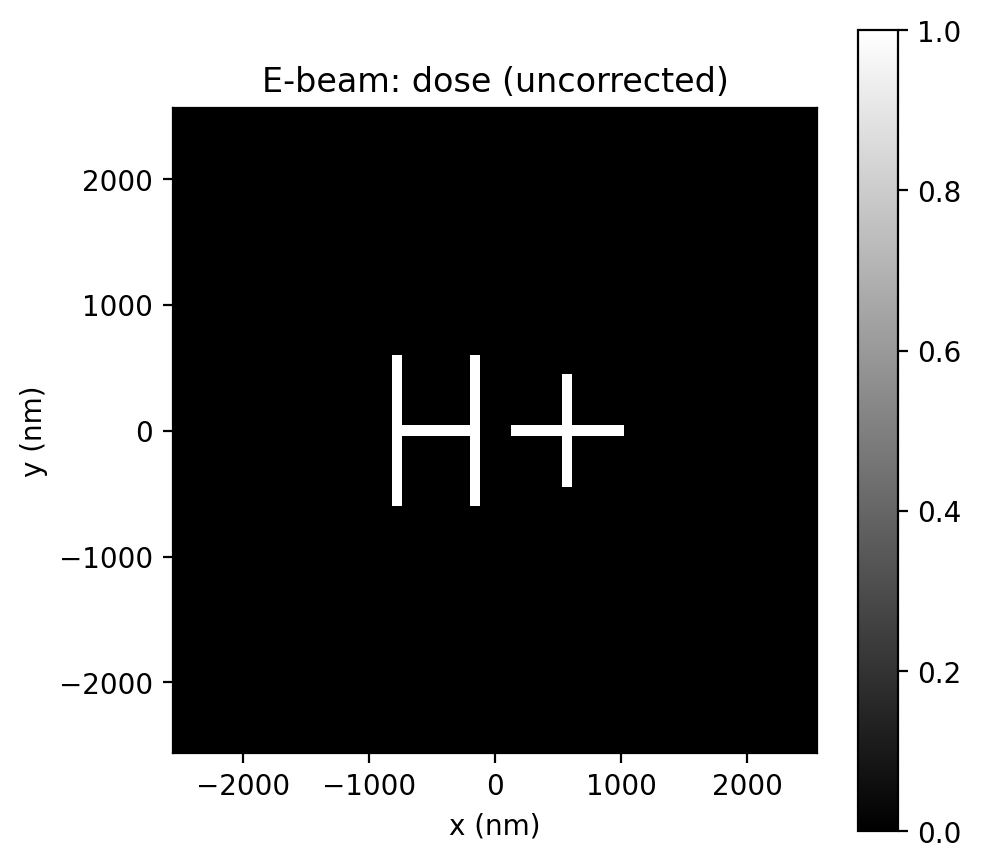

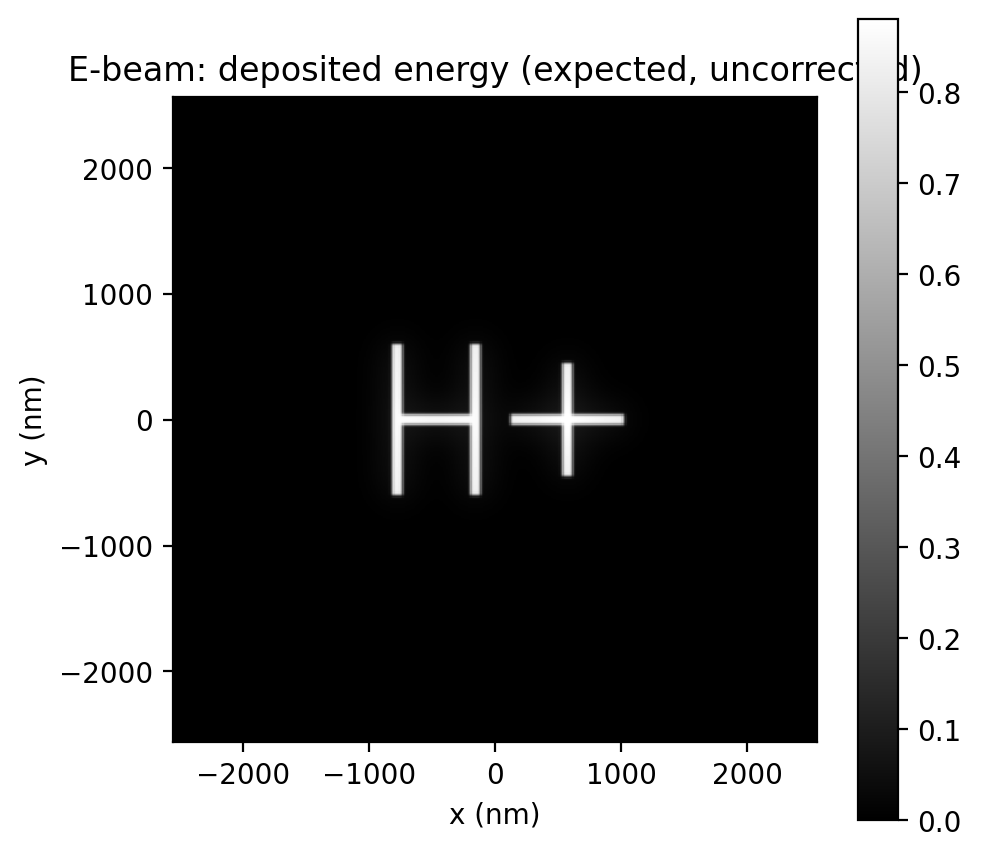

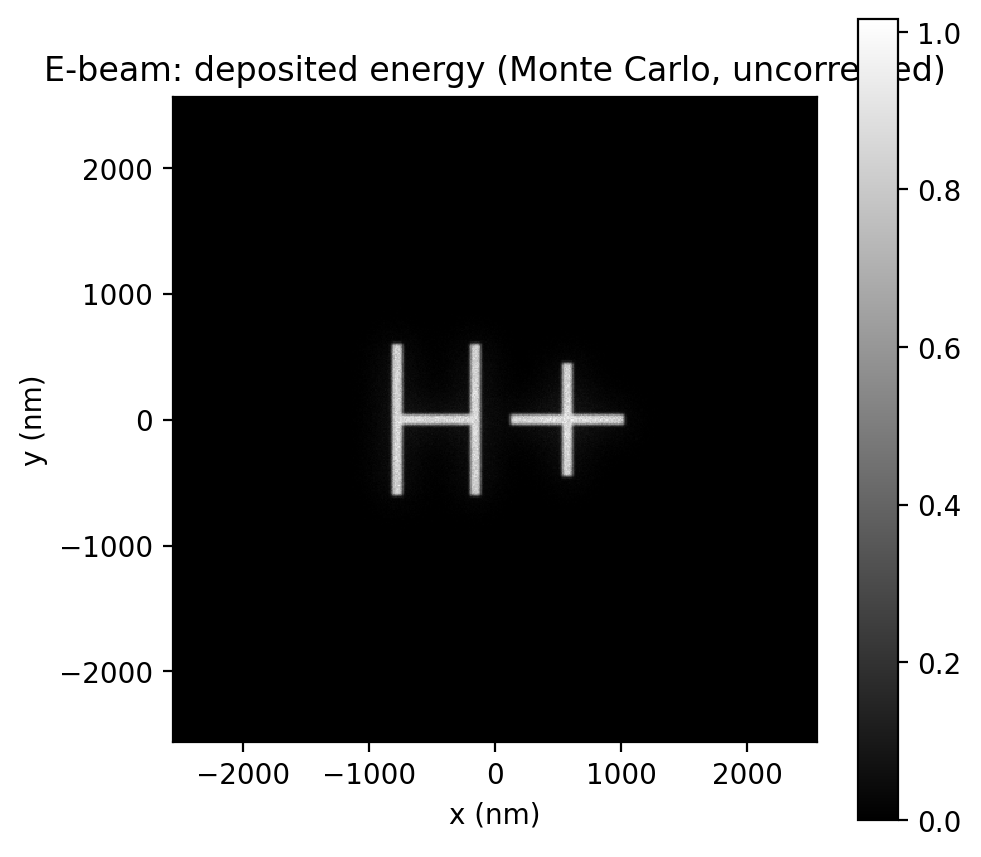

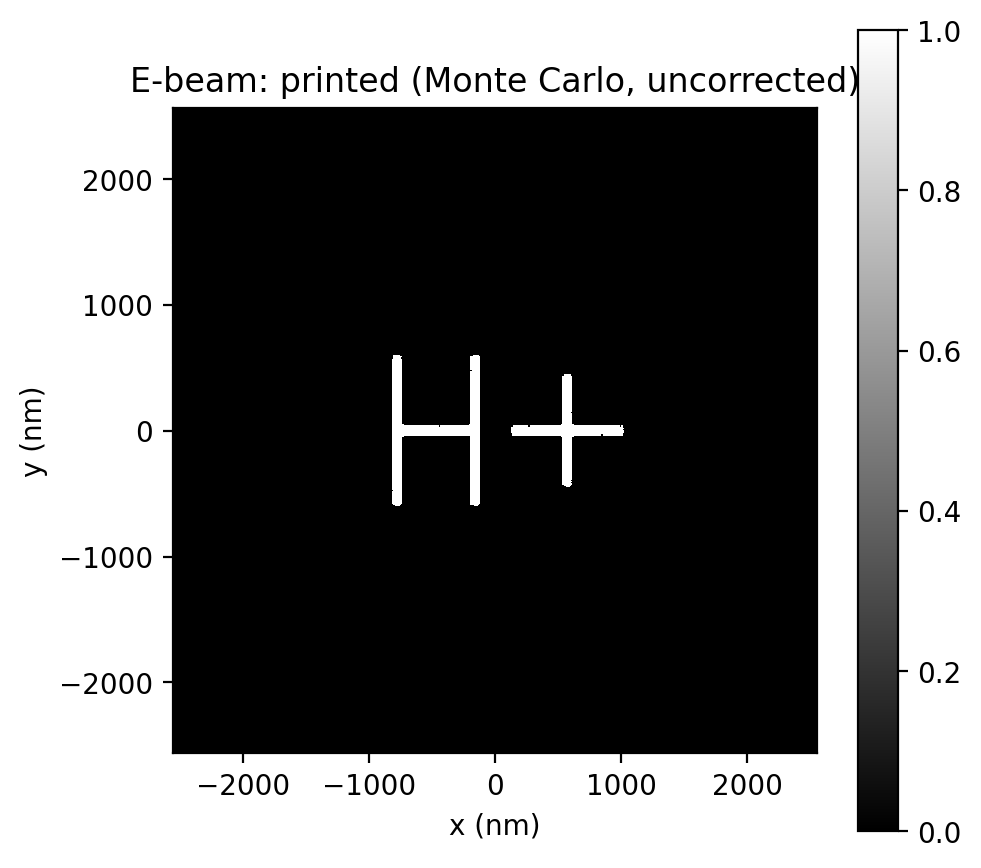

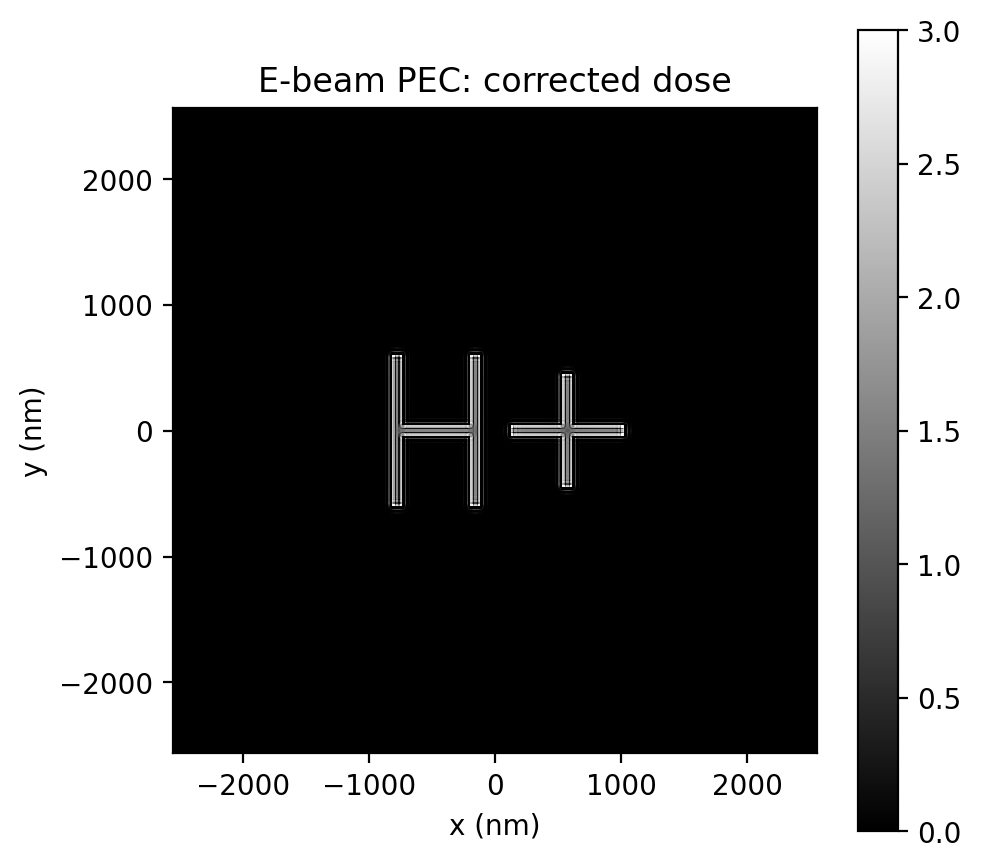

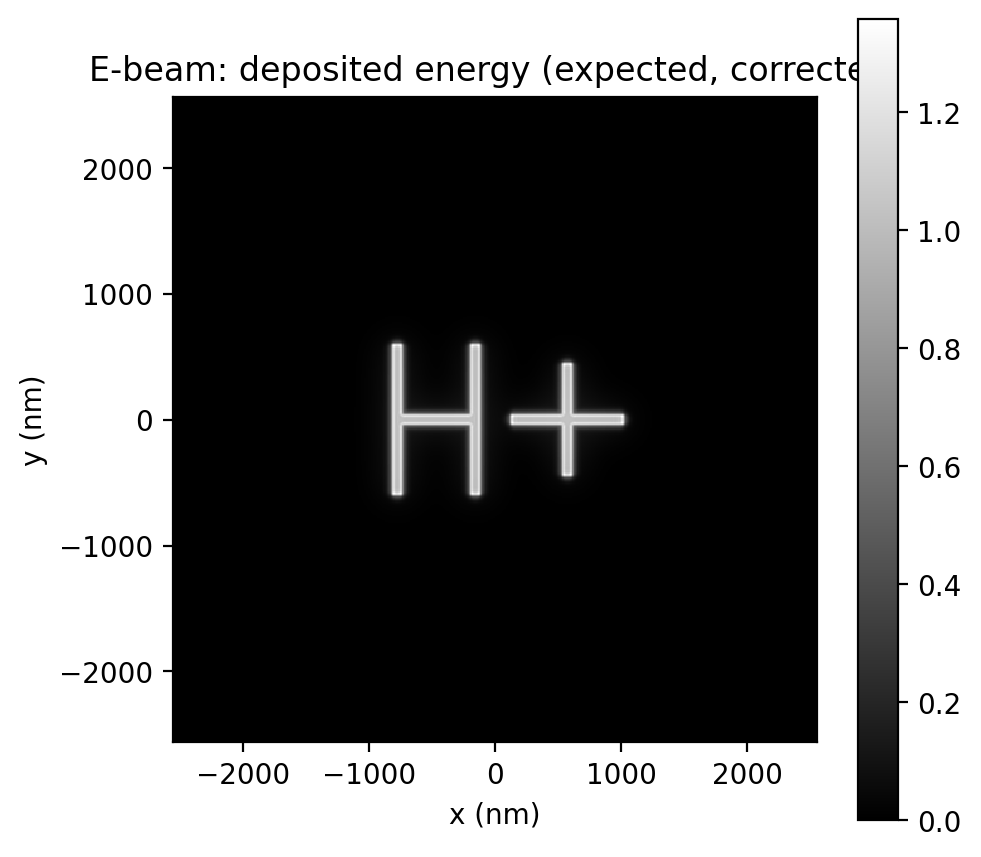

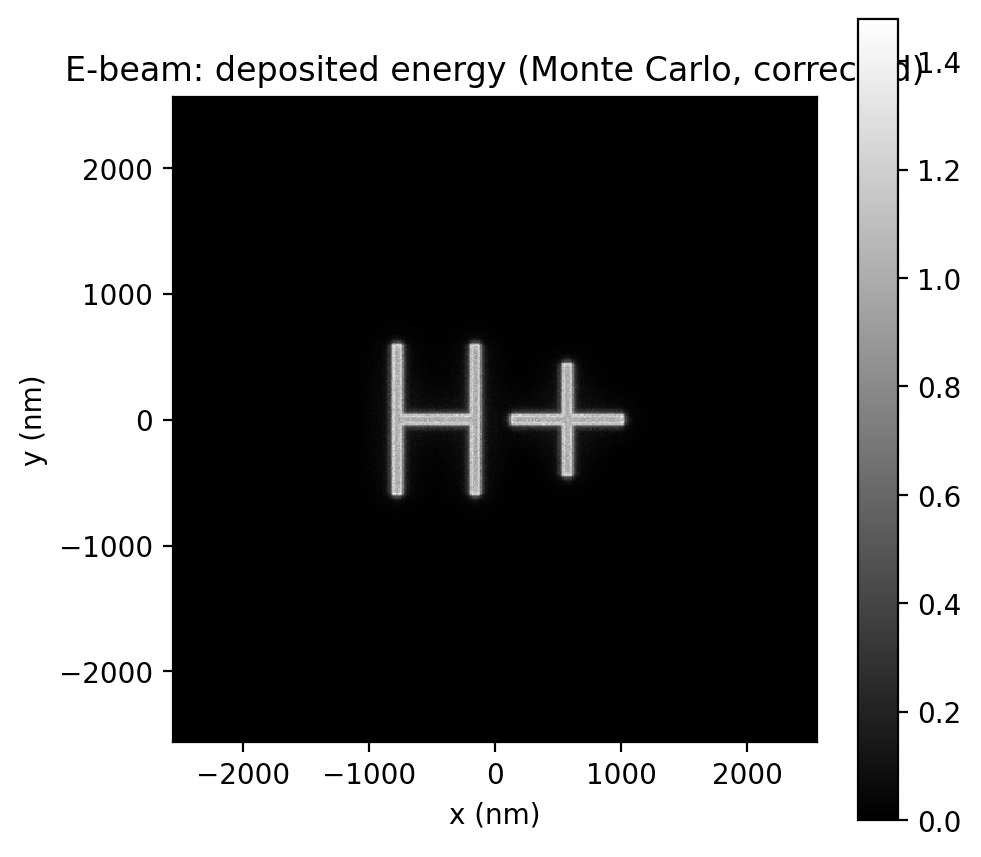

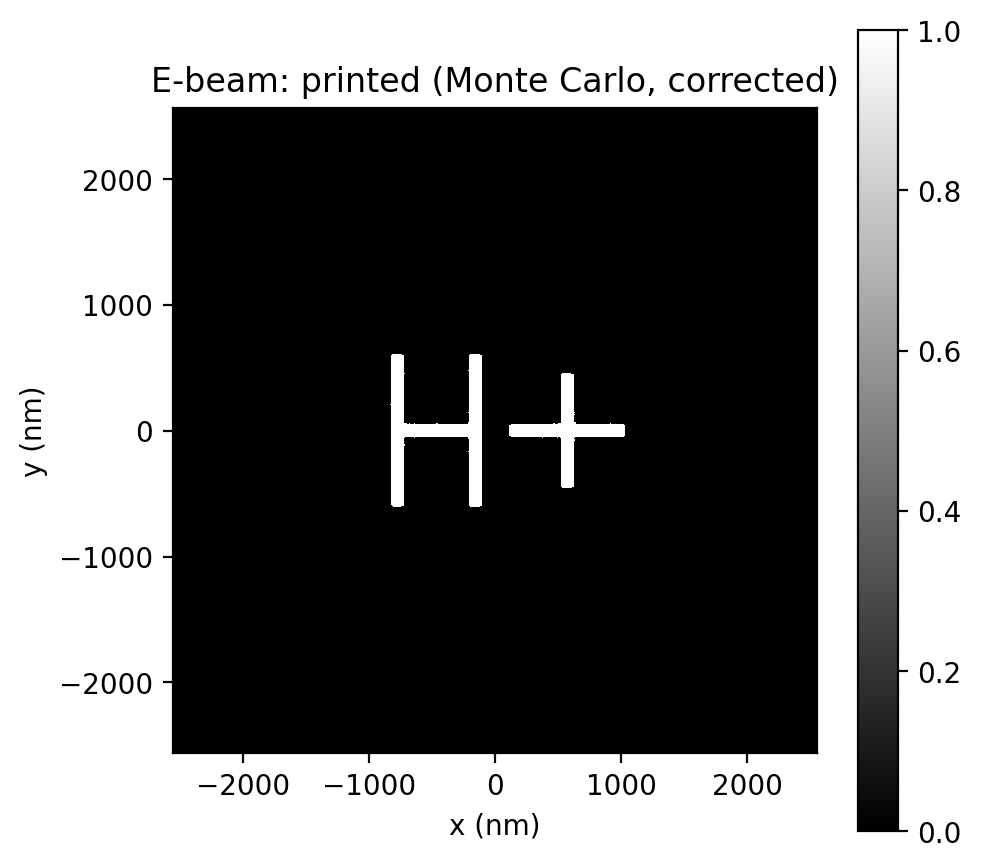

In [18]:
def show_image(title: str, img, extent_nm: float) -> None:
    plt.figure(figsize=(5.2, 5.2))
    plt.title(title)
    plt.imshow(to_cpu(img), extent=[-extent_nm/2, extent_nm/2, -extent_nm/2, extent_nm/2], interpolation="nearest")
    plt.xlabel("x (nm)")
    plt.ylabel("y (nm)")
    plt.colorbar()
    plt.show()


extent_nm = CFG.grid_n * CFG.pixel_nm

# Target
show_image("Target pattern: H +", target, extent_nm)

# Optical results
show_image("Optical: expected aerial (uncorrected)", opt_expected_unc, extent_nm)
show_image("Optical: Monte Carlo aerial (uncorrected)", opt_noisy_unc, extent_nm)
show_image("Optical: printed (uncorrected)", opt_print_unc, extent_nm)

show_image("Optical OPC: corrected grayscale mask", opt_mask_corr, extent_nm)
show_image("Optical: Monte Carlo aerial (corrected)", opt_noisy_cor, extent_nm)
show_image("Optical: printed (corrected)", opt_print_cor, extent_nm)

# E-beam results
show_image("E-beam: dose (uncorrected)", eb_dose_unc, extent_nm)
show_image("E-beam: deposited energy (expected, uncorrected)", eb_energy_expected_unc, extent_nm)
show_image("E-beam: deposited energy (Monte Carlo, uncorrected)", eb_energy_mc_unc, extent_nm)
show_image("E-beam: printed (Monte Carlo, uncorrected)", eb_print_unc, extent_nm)

show_image("E-beam PEC: corrected dose", eb_dose_cor, extent_nm)
show_image("E-beam: deposited energy (expected, corrected)", eb_energy_expected_cor, extent_nm)
show_image("E-beam: deposited energy (Monte Carlo, corrected)", eb_energy_mc_cor, extent_nm)
show_image("E-beam: printed (Monte Carlo, corrected)", eb_print_cor, extent_nm)


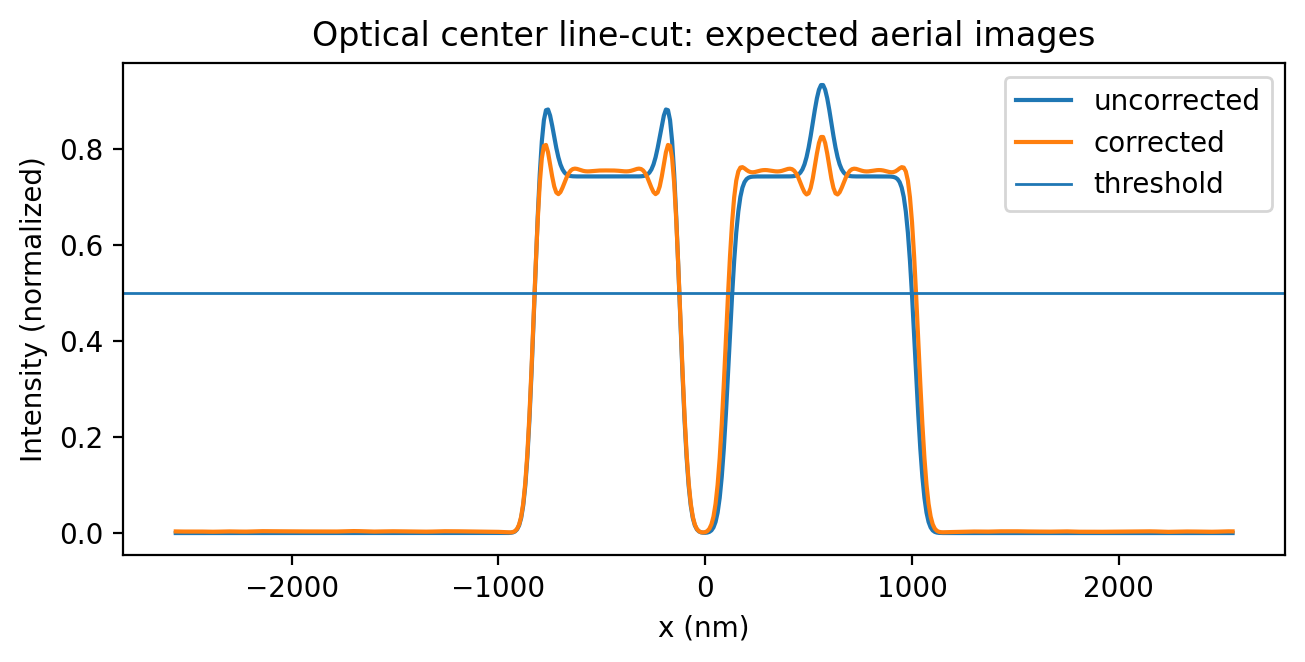

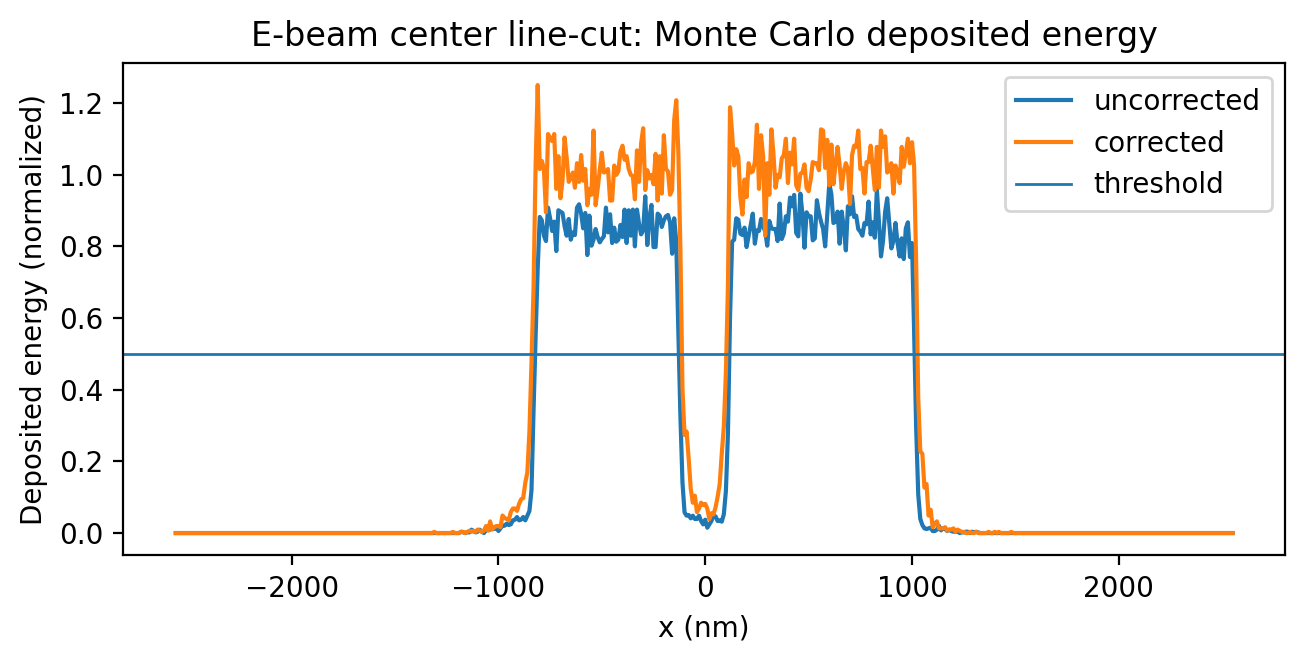

In [19]:
y0 = CFG.grid_n // 2

x_nm = (np.arange(CFG.grid_n) - CFG.grid_n // 2) * CFG.pixel_nm

plt.figure(figsize=(7.5, 3.2))
plt.title("Optical center line-cut: expected aerial images")
plt.plot(x_nm, to_cpu(opt_expected_unc)[y0, :], label="uncorrected")
plt.plot(x_nm, to_cpu(opt_expected_cor)[y0, :], label="corrected")
plt.axhline(CFG.opt_threshold, linewidth=1.0, label="threshold")
plt.xlabel("x (nm)")
plt.ylabel("Intensity (normalized)")
plt.legend()
plt.show()

plt.figure(figsize=(7.5, 3.2))
plt.title("E-beam center line-cut: Monte Carlo deposited energy")
plt.plot(x_nm, to_cpu(eb_energy_mc_unc)[y0, :], label="uncorrected")
plt.plot(x_nm, to_cpu(eb_energy_mc_cor)[y0, :], label="corrected")
plt.axhline(CFG.eb_threshold, linewidth=1.0, label="threshold")
plt.xlabel("x (nm)")
plt.ylabel("Deposited energy (normalized)")
plt.legend()
plt.show()
